Importación de librerías y Carga de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para gráficos más profesionales
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

# Ruta del archivo
ruta_archivo = '/content/base-anuario-de-siniestralidad-2024.xlsx'

print("Iniciando la carga de datos... por favor espera.")

# Carga de las hojas
df_siniestros = pd.read_excel(ruta_archivo, sheet_name='Siniestros')
print(f"✅ Siniestros cargados: {df_siniestros.shape[0]} filas, {df_siniestros.shape[1]} columnas")

df_vehiculos = pd.read_excel(ruta_archivo, sheet_name='Vehiculos')
print(f"✅ Vehículos cargados: {df_vehiculos.shape[0]} filas, {df_vehiculos.shape[1]} columnas")

df_actores = pd.read_excel(ruta_archivo, sheet_name='Actor_vial')
print(f"✅ Actores Viales cargados: {df_actores.shape[0]} filas, {df_actores.shape[1]} columnas")

Iniciando la carga de datos... por favor espera.
✅ Siniestros cargados: 82371 filas, 40 columnas
✅ Vehículos cargados: 151363 filas, 32 columnas
✅ Actores Viales cargados: 185517 filas, 44 columnas


Celda 2: Inspección de Calidad de Datos (Valores Nulos)

In [ ]:
print("--- ANÁLISIS DE VALORES NULOS EN SINIESTROS ---")
# Filtramos solo las columnas que tienen al menos un valor nulo
nulos_siniestros = df_siniestros.isnull().sum()
nulos_siniestros = nulos_siniestros[nulos_siniestros > 0].sort_values(ascending=False)

if not nulos_siniestros.empty:
    nulos_df = pd.DataFrame({'Valores Nulos': nulos_siniestros,
                             '% del Total': (nulos_siniestros / len(df_siniestros)) * 100})
    display(nulos_df.round(2))
else:
    print("No se encontraron valores nulos en el dataset de Siniestros.")

# Verificamos si hay duplicados en la llave primaria
duplicados = df_siniestros['Codigo_Accidente'].duplicated().sum()
print(f"\nCódigos de accidente duplicados: {duplicados}")

--- ANÁLISIS DE VALORES NULOS EN SINIESTROS ---


,Valores Nulos,% del Total
Con_Rutas,82353,99.98
Con_Padron_Dual,82136,99.71
Con_Articulado,82013,99.57
Con_Velocidad,82008,99.56
Con_Provisional,81975,99.52
Con_Biarticulado,81789,99.29
Con_Huecos,81512,98.96
Con_Alimentador,81351,98.76
Con_Troncal,81205,98.58
Con_Servicio_Especial,80654,97.92



Códigos de accidente duplicados: 0


Análisis de la Variable Objetivo (Severidad)
Vamos a evaluar el desbalanceo de nuestra variable a predecir.

,Cantidad,Porcentaje (%)
Gravedad_Indicador_Tradicional,,
Con Heridos,48158,58.46
Solo Daños,32096,38.97
Con Muertos,2117,2.57


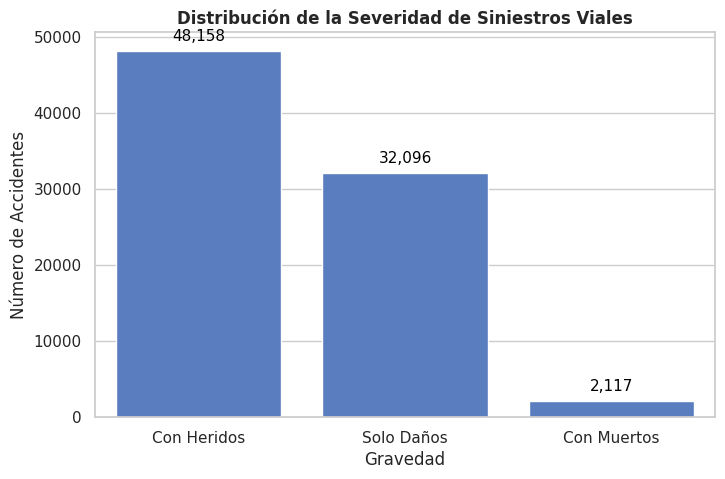

In [ ]:
# Analizamos la variable Target
target_col = 'Gravedad_Indicador_Tradicional'

# Tabla de frecuencias
frecuencia_target = df_siniestros[target_col].value_counts()
porcentaje_target = df_siniestros[target_col].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({'Cantidad': frecuencia_target, 'Porcentaje (%)': porcentaje_target.round(2)})
display(resumen_target)

# Gráfico de la variable objetivo
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=resumen_target.index, y=resumen_target['Cantidad'])
plt.title('Distribución de la Severidad de Siniestros Viales', fontweight='bold')
plt.ylabel('Número de Accidentes')
plt.xlabel('Gravedad')

# Agregar los valores numéricos sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

Análisis Temporal (Cuándo ocurren los siniestros más graves)
Esto nos ayudará a identificar patrones. Convertimos variables a formatos manejables y graficamos.

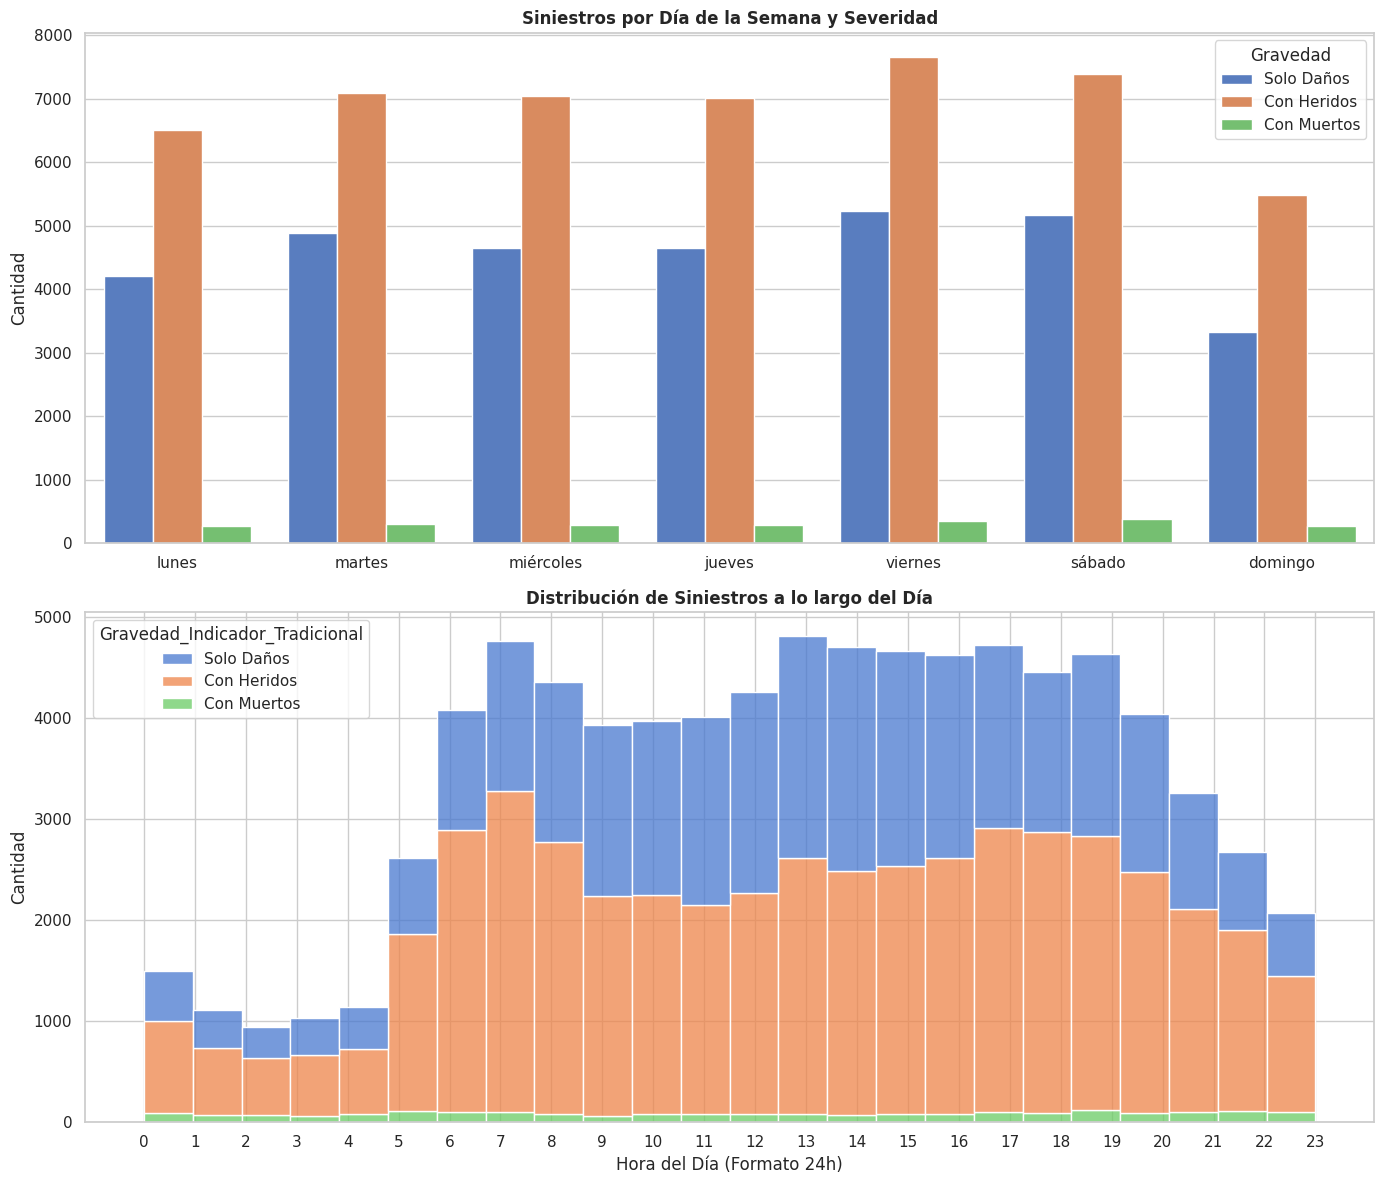

In [ ]:
# Ordenar lógicamente los días de la semana
orden_dias = ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo']

# Subplots para analizar días y horas
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Siniestros por Día de la Semana
sns.countplot(data=df_siniestros, x='Dia_Semana_Acc', order=orden_dias,
              hue='Gravedad_Indicador_Tradicional', ax=axes[0])
axes[0].set_title('Siniestros por Día de la Semana y Severidad', fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlabel('')
axes[0].legend(title='Gravedad')

# 2. Siniestros por Hora del Día (Aseguramos que la hora sea numérica)
df_siniestros['Hora_Acc'] = pd.to_numeric(df_siniestros['Hora_Acc'], errors='coerce')
sns.histplot(data=df_siniestros, x='Hora_Acc', bins=24,
             hue='Gravedad_Indicador_Tradicional', multiple="stack", ax=axes[1])
axes[1].set_title('Distribución de Siniestros a lo largo del Día', fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].set_xlabel('Hora del Día (Formato 24h)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

Análisis Geográfico y Relacional (Localidades y Actores)
Finalmente, cruzaremos información de la tabla principal con el recuento de actores viales para ver cómo interactúan.

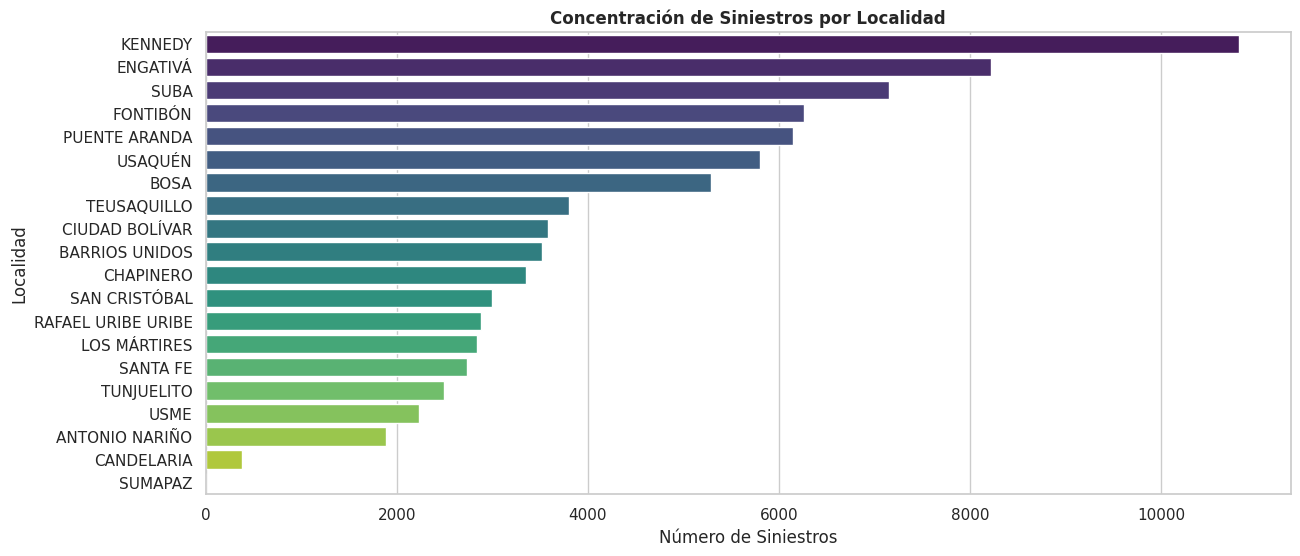


--- Relación: Gravedad vs Número Promedio de Vehículos Involucrados ---


,Gravedad_Indicador_Tradicional,Num_Vehiculos_Involucrados
0,Con Heridos,1.73
1,Con Muertos,1.56
2,Solo Daños,2.01


In [ ]:
# 1. Top Localidades con más siniestros
plt.figure(figsize=(14, 6))
orden_localidades = df_siniestros['Localidad'].value_counts().index
sns.countplot(data=df_siniestros, y='Localidad', order=orden_localidades, palette="viridis")
plt.title('Concentración de Siniestros por Localidad', fontweight='bold')
plt.xlabel('Número de Siniestros')
plt.ylabel('Localidad')
plt.show()

# 2. Creación de una variable derivada cruzando tablas (Feature Engineering básico)
# Contamos cuántos vehículos estuvieron involucrados por cada accidente
conteo_vehiculos = df_vehiculos.groupby('Codigo_Accidente').size().reset_index(name='Num_Vehiculos_Involucrados')

# Unimos esta nueva variable a nuestra tabla principal de siniestros
df_siniestros_analisis = df_siniestros.merge(conteo_vehiculos, on='Codigo_Accidente', how='left')
# Llenamos con 0 en caso de que algún siniestro no tenga vehículos registrados (ej. caídas de peatones aisladas)
df_siniestros_analisis['Num_Vehiculos_Involucrados'] = df_siniestros_analisis['Num_Vehiculos_Involucrados'].fillna(0)

print("\n--- Relación: Gravedad vs Número Promedio de Vehículos Involucrados ---")
display(df_siniestros_analisis.groupby('Gravedad_Indicador_Tradicional')['Num_Vehiculos_Involucrados'].mean().round(2).reset_index())

In [ ]:
import folium
from folium.plugins import HeatMap
import pandas as pd

print("Preparando el mapa de Bogotá...")

# 1. Limpiar coordenadas: Asegurarnos de que no hay nulos y están dentro de Bogotá
# (Latitud aprox entre 4.4 y 4.9, Longitud entre -74.3 y -73.9)
df_mapa = df_siniestros.dropna(subset=['Latitud', 'Longitud'])
df_mapa = df_mapa[(df_mapa['Latitud'] > 4.4) & (df_mapa['Latitud'] < 4.9) &
                  (df_mapa['Longitud'] > -74.3) & (df_mapa['Longitud'] < -73.9)]

# 2. Crear el mapa base centrado en Bogotá
# El estilo 'cartodbpositron' es limpio, gris/blanco, ideal para resaltar datos.
mapa_bogota = folium.Map(location=[4.6097, -74.0817], zoom_start=11, tiles='cartodbpositron')

# 3. Crear el Mapa de Calor
# Tomamos una muestra de 20,000 siniestros para que Colab no se sature,
# pero la distribución espacial se mantendrá idéntica.
muestra_heatmap = df_mapa.sample(n=20000, random_state=42)
heat_data = [[row['Latitud'], row['Longitud']] for index, row in muestra_heatmap.iterrows()]

# Añadir la capa de calor al mapa
HeatMap(heat_data,
        radius=12,
        blur=10,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 1.0: 'red'}
       ).add_to(mapa_bogota)

# Mostrar el mapa (puedes hacer zoom y moverte)
mapa_bogota

Preparando el mapa de Bogotá...


In [ ]:
import plotly.express as px

print("Generando gráfico interactivo por localidades...")

# 1. Agrupar los datos por Localidad y Gravedad
resumen_localidad = df_siniestros.groupby(['Localidad', 'Gravedad_Indicador_Tradicional']).size().reset_index(name='Cantidad_Siniestros')

# 2. Filtrar si hay localidades extrañas o nulas (a veces aparece 'Sin Localidad' o nulos)
resumen_localidad = resumen_localidad.dropna(subset=['Localidad'])

# 3. Crear el gráfico de barras apiladas horizontal
fig = px.bar(resumen_localidad,
             y='Localidad',
             x='Cantidad_Siniestros',
             color='Gravedad_Indicador_Tradicional',
             title='<b>Distribución de Siniestros por Localidad y Gravedad</b>',
             orientation='h',
             text_auto=True, # Muestra el número dentro de la barra
             color_discrete_map={
                 'Solo Daños': '#A6B8C7', # Gris azulado
                 'Con Heridos': '#F2A900', # Amarillo/Naranja
                 'Con Muertos': '#D9534F'  # Rojo
             })

# 4. Configurar el diseño para que se ordene de mayor a menor y sea más alto
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, # Ordena las localidades de la que tiene menos a la que tiene más
    height=700, # Altura del gráfico para que quepan bien todas las localidades
    plot_bgcolor='white',
    legend_title_text='Gravedad del Siniestro'
)

# Mostrar el gráfico
fig.show()

Generando gráfico interactivo por localidades...


In [ ]:
import folium
import geopandas as gpd
import pandas as pd

print("Descargando polígonos oficiales de Datos Abiertos Bogotá...")

# 1. Agrupar los datos para tener el total por localidad
resumen_localidad = df_siniestros.groupby('Localidad').size().reset_index(name='Cantidad_Siniestros')

# Limpieza de tus datos: Mayúsculas y sin tildes para evitar errores de cruce
resumen_localidad['Localidad'] = resumen_localidad['Localidad'].str.upper().str.strip()
reemplazos = {'Á':'A', 'É':'E', 'Í':'I', 'Ó':'O', 'Ú':'U'}
resumen_localidad['Localidad'] = resumen_localidad['Localidad'].replace(reemplazos, regex=True)

# 2. Cargar el GeoJSON usando una URL oficial y estable del Distrito
url_geojson = 'https://datosabiertos.bogota.gov.co/dataset/856cb657-8ca3-4ee8-857f-37211173b1f8/resource/497b8756-0927-4aee-8da9-ca4e32ca3a8a/download/loca.geojson'

# GeoPandas lee el archivo espacial directamente
gdf_localidades = gpd.read_file(url_geojson)

# Limpiamos también los nombres en el mapa oficial para que el cruce sea 100% exacto
# En el archivo del Distrito, la columna se llama 'LocNombre'
gdf_localidades['LocNombre'] = gdf_localidades['LocNombre'].str.upper().str.strip()
gdf_localidades['LocNombre'] = gdf_localidades['LocNombre'].replace(reemplazos, regex=True)

# 3. Crear el mapa base centrado en Bogotá
mapa_siluetas = folium.Map(location=[4.6097, -74.0817], zoom_start=11, tiles='cartodbpositron')

# 4. Crear la capa Coroplética
folium.Choropleth(
    geo_data=gdf_localidades.to_json(), # Pasamos el mapa ya estructurado y limpio
    name='Siniestros por Localidad',
    data=resumen_localidad,
    columns=['Localidad', 'Cantidad_Siniestros'],
    key_on='feature.properties.LocNombre', # Llave de cruce
    fill_color='YlOrRd',  # Paleta: Amarillo a Rojo
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name='Total de Siniestros Viales (2024)'
).add_to(mapa_siluetas)

# Agregar el control de capas
folium.LayerControl().add_to(mapa_siluetas)

print("¡Mapa generado con éxito!")
# Mostrar el mapa
mapa_siluetas

Descargando polígonos oficiales de Datos Abiertos Bogotá...
¡Mapa generado con éxito!


In [ ]:
import folium
import geopandas as gpd
import pandas as pd
from folium.features import DivIcon

print("Generando Mapa Coroplético con etiquetas de texto...")

# 1. Agrupar los datos (tu base original de siniestros)
resumen_localidad = df_siniestros.groupby('Localidad').size().reset_index(name='Cantidad_Siniestros')
resumen_localidad['Localidad'] = resumen_localidad['Localidad'].str.upper().str.strip()
reemplazos = {'Á':'A', 'É':'E', 'Í':'I', 'Ó':'O', 'Ú':'U'}
resumen_localidad['Localidad'] = resumen_localidad['Localidad'].replace(reemplazos, regex=True)

# 2. Cargar el GeoJSON oficial
url_geojson = 'https://datosabiertos.bogota.gov.co/dataset/856cb657-8ca3-4ee8-857f-37211173b1f8/resource/497b8756-0927-4aee-8da9-ca4e32ca3a8a/download/loca.geojson'
gdf_localidades = gpd.read_file(url_geojson)

# Limpiar nombres del mapa para cruce exacto
gdf_localidades['LocNombre'] = gdf_localidades['LocNombre'].str.upper().str.strip()
gdf_localidades['LocNombre'] = gdf_localidades['LocNombre'].replace(reemplazos, regex=True)

# 3. Unir la geometría con tu tabla de accidentes
gdf_merged = gdf_localidades.merge(resumen_localidad, left_on='LocNombre', right_on='Localidad', how='left')
gdf_merged['Cantidad_Siniestros'] = gdf_merged['Cantidad_Siniestros'].fillna(0) # Poner 0 si hay alguna vacía

# 4. Crear el mapa base
mapa_etiquetas = folium.Map(location=[4.6097, -74.0817], zoom_start=11, tiles='cartodbpositron')

# 5. Capa de Color (Choropleth)
folium.Choropleth(
    geo_data=gdf_localidades.to_json(),
    name='Siniestros por Localidad',
    data=resumen_localidad,
    columns=['Localidad', 'Cantidad_Siniestros'],
    key_on='feature.properties.LocNombre',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name='Total de Siniestros Viales (2024)'
).add_to(mapa_etiquetas)

# 6. Capa de Texto (Números y Nombres)
for idx, row in gdf_merged.iterrows():
    # Encontrar un punto dentro del polígono para poner el texto
    punto = row.geometry.representative_point()
    lat, lon = punto.y, punto.x

    # Darle formato al texto (Nombre de localidad y número con separador de miles)
    nombre_loc = row['LocNombre'].title()
    cantidad = int(row['Cantidad_Siniestros'])

    # CSS para las letras: negrita, color negro y borde blanco fuerte
    estilo_texto = f"""
        <div style="
            font-size: 9pt;
            font-weight: bold;
            color: black;
            text-shadow: 2px 0 #fff, -2px 0 #fff, 0 2px #fff, 0 -2px #fff, 1px 1px #fff, -1px -1px #fff, 1px -1px #fff, -1px 1px #fff;
            text-align: center;
            width: 120px;
            margin-left: -60px;
        ">
            {nombre_loc}<br>{cantidad:,}
        </div>
    """

    # Agregar el texto al mapa
    folium.Marker(
        location=[lat, lon],
        icon=DivIcon(html=estilo_texto)
    ).add_to(mapa_etiquetas)

# Control de capas
folium.LayerControl().add_to(mapa_etiquetas)

print("¡Mapa con etiquetas generado con éxito!")

# Mostrar mapa
mapa_etiquetas

Generando Mapa Coroplético con etiquetas de texto...
¡Mapa con etiquetas generado con éxito!


1. GENERANDO ESTADÍSTICAS DESCRIPTIVAS (describe)...


,Codigo_Accidente,Formulario,Longitud,Latitud,Direccion,Fecha_Acc,AA_Acc,MM_Acc,DD_Mes_Acc,Dia_Semana_Acc,...,Con_Sitp,Con_Troncal,Con_Alimentador,Con_Zonal,Con_Provisional,Con_Articulado,Con_Biarticulado,Con_Padron_Dual,Con_Servicio_Especial,Con_Taxi
count,8.237100e+04,82371,82371.000000,82371.000000,82371,82371,82371.000000,82371,82371.00000,82371,...,12951,1166,1020,10489,396,358,582,235,1717,12227
unique,NaN,82371,NaN,NaN,45269,NaN,NaN,12,NaN,7,...,1,1,1,1,1,1,1,1,1,1
top,NaN,A001345254,NaN,NaN,KR 3 E- CL 91 02,NaN,NaN,Marzo,NaN,viernes,...,SI,SI,SI,SI,SI,SI,SI,SI,SI,SI
freq,NaN,1,NaN,NaN,76,NaN,NaN,7834,NaN,13224,...,12951,1166,1020,10489,396,358,582,235,1717,12227
mean,1.057260e+07,NaN,-74.109519,4.641418,NaN,2022-08-28 17:22:37.162108160,2022.159729,NaN,15.79290,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.053079e+07,NaN,-74.247270,4.043953,NaN,2021-01-01 00:00:00,2021.000000,NaN,1.00000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.055173e+07,NaN,-74.138000,4.600601,NaN,2021-10-05 00:00:00,2021.000000,NaN,8.00000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.057256e+07,NaN,-74.107983,4.632843,NaN,2022-06-01 00:00:00,2022.000000,NaN,16.00000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.059348e+07,NaN,-74.081000,4.684435,NaN,2023-07-11 00:00:00,2023.000000,NaN,23.00000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.061625e+07,NaN,-74.007000,4.825000,NaN,2024-12-31 00:00:00,2024.000000,NaN,31.00000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



2. GENERANDO HISTOGRAMAS DE VARIABLES IMPORTANTES...


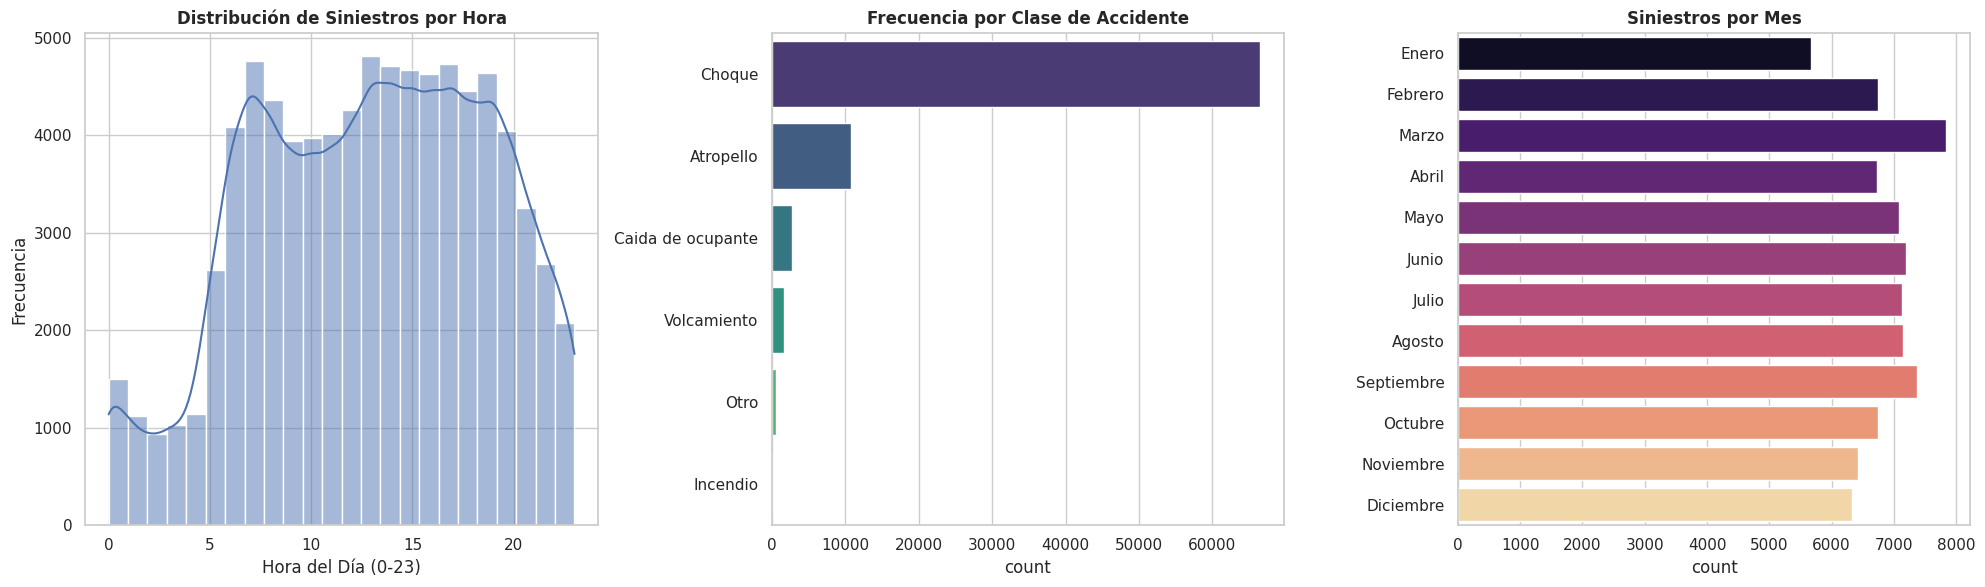


3. PREPARANDO DATOS Y GENERANDO HEATMAP DE CORRELACIONES...


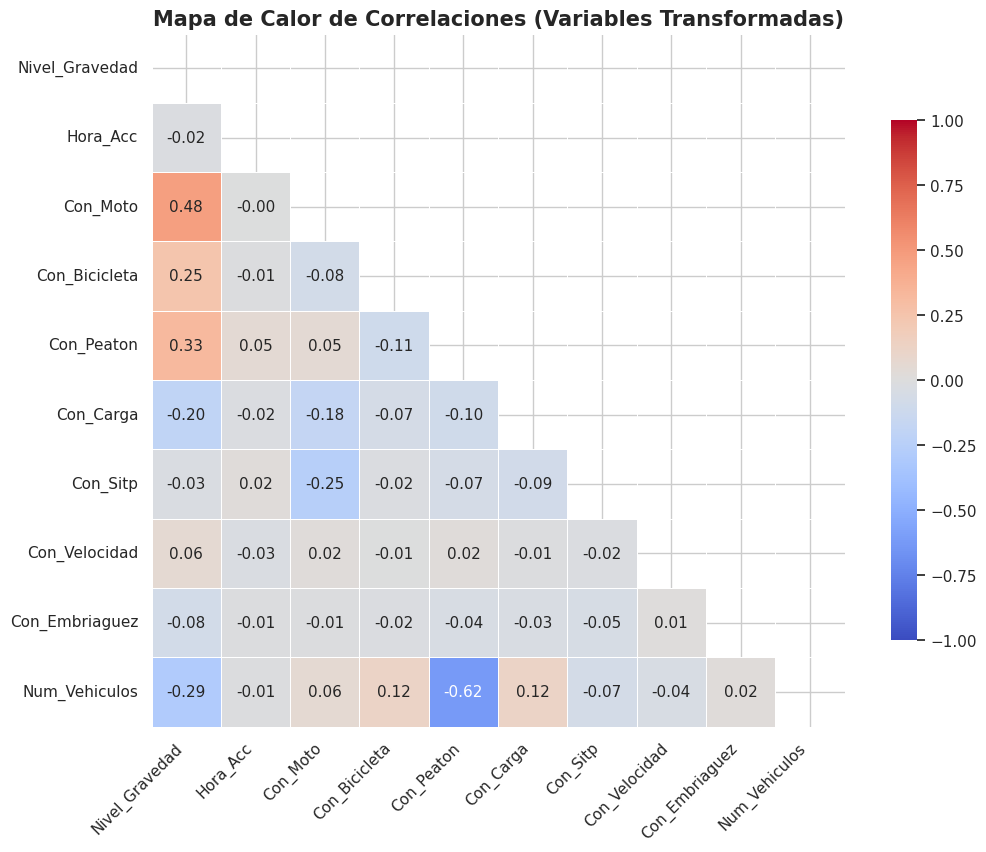

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 11})

print("1. GENERANDO ESTADÍSTICAS DESCRIPTIVAS (describe)...")
# Usamos include='all' para ver tanto métricas numéricas como categóricas
resumen_estadistico = df_siniestros.describe(include='all')
display(resumen_estadistico)

print("\n2. GENERANDO HISTOGRAMAS DE VARIABLES IMPORTANTES...")
# Creamos un lienzo con 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Asegurarnos de que la hora sea numérica
df_siniestros['Hora_Acc'] = pd.to_numeric(df_siniestros['Hora_Acc'], errors='coerce')

# Gráfico 1: Histograma de Horas
sns.histplot(df_siniestros['Hora_Acc'].dropna(), bins=24, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de Siniestros por Hora', fontweight='bold')
axes[0].set_xlabel('Hora del Día (0-23)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Clase de Accidente
orden_clase = df_siniestros['Clase_Acc'].value_counts().index
sns.countplot(y=df_siniestros['Clase_Acc'], order=orden_clase, ax=axes[1], palette='viridis')
axes[1].set_title('Frecuencia por Clase de Accidente', fontweight='bold')
axes[1].set_ylabel('')

# Gráfico 3: Siniestros por Mes
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
sns.countplot(y=df_siniestros['MM_Acc'], order=orden_meses, ax=axes[2], palette='magma')
axes[2].set_title('Siniestros por Mes', fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n3. PREPARANDO DATOS Y GENERANDO HEATMAP DE CORRELACIONES...")

# --- FEATURE ENGINEERING PARA LA CORRELACIÓN ---
df_corr = pd.DataFrame()

# A. Convertir la Gravedad a ordinal (1 = Solo Daños, 2 = Heridos, 3 = Muertos)
mapa_gravedad = {'Solo Daños': 1, 'Con Heridos': 2, 'Con Muertos': 3}
df_corr['Nivel_Gravedad'] = df_siniestros['Gravedad_Indicador_Tradicional'].map(mapa_gravedad)

# B. Añadir la hora
df_corr['Hora_Acc'] = df_siniestros['Hora_Acc']

# C. Convertir las variables de los actores viales y causas ('SI' -> 1, NaN -> 0)
variables_binarias = ['Con_Moto', 'Con_Bicicleta', 'Con_Peaton', 'Con_Carga', 'Con_Sitp', 'Con_Velocidad', 'Con_Embriaguez']
for col in variables_binarias:
    if col in df_siniestros.columns:
        df_corr[col] = df_siniestros[col].apply(lambda x: 1 if x == 'SI' else 0)

# D. Cruzar con el número de vehículos involucrados (desde la tabla df_vehiculos)
conteo_veh = df_vehiculos.groupby('Codigo_Accidente').size().reset_index(name='Num_Vehiculos')
temp_siniestros = df_siniestros[['Codigo_Accidente']].merge(conteo_veh, on='Codigo_Accidente', how='left')
df_corr['Num_Vehiculos'] = temp_siniestros['Num_Vehiculos'].fillna(0)

# Calcular la matriz de correlación (Método Spearman suele ser mejor para variables ordinales)
matriz_corr = df_corr.corr(method='spearman')

# Dibujar el Heatmap
plt.figure(figsize=(12, 9))
# Usamos una máscara para tapar la mitad superior repetida y que se vea más profesional
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Mapa de Calor de Correlaciones (Variables Transformadas)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

Preparación de Datos (Data Preprocessing)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

print("1. PREPARANDO LOS DATOS PARA LOS MODELOS...")

# 1. Asegurar la variable de Número de Vehículos directamente desde df_vehiculos
conteo_veh = df_vehiculos.groupby('Codigo_Accidente').size().reset_index(name='Num_Vehiculos')
df_preparacion = df_siniestros.merge(conteo_veh, on='Codigo_Accidente', how='left')
df_preparacion['Num_Vehiculos'] = df_preparacion['Num_Vehiculos'].fillna(0)

# 2. Seleccionar variables predictoras (Features)
variables_usar = ['Gravedad_Indicador_Tradicional', 'Hora_Acc', 'Dia_Semana_Acc',
                  'Clase_Acc', 'Num_Vehiculos']
variables_binarias = ['Con_Moto', 'Con_Bicicleta', 'Con_Peaton', 'Con_Carga', 'Con_Sitp']

# Crear un nuevo dataframe limpio solo con lo que necesitamos
df_ml = df_preparacion[variables_usar + variables_binarias].copy()

# 3. Limpieza y Transformación
df_ml['Hora_Acc'] = pd.to_numeric(df_ml['Hora_Acc'], errors='coerce')
df_ml = df_ml.dropna(subset=['Hora_Acc', 'Gravedad_Indicador_Tradicional'])

for col in variables_binarias:
    df_ml[col] = df_ml[col].apply(lambda x: 1 if x == 'SI' else 0)

# 4. Codificar variables categóricas (One-Hot Encoding para Día y Clase de Accidente)
df_ml = pd.get_dummies(df_ml, columns=['Dia_Semana_Acc', 'Clase_Acc'], drop_first=True)

# 5. Codificar la Variable Objetivo a números (0, 1, 2)
mapa_target = {'Solo Daños': 0, 'Con Heridos': 1, 'Con Muertos': 2}
df_ml['Target'] = df_ml['Gravedad_Indicador_Tradicional'].map(mapa_target)

# Separar X (predictoras) y y (objetivo)
X = df_ml.drop(['Gravedad_Indicador_Tradicional', 'Target'], axis=1)
y = df_ml['Target']

# 6. Partición de Datos (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"✅ Datos listos: {X_train.shape[0]} para entrenar y {X_test.shape[0]} para probar.")
print(f"✅ Cantidad de variables predictoras: {X_train.shape[1]}")

1. PREPARANDO LOS DATOS PARA LOS MODELOS...
✅ Datos listos: 65896 para entrenar y 16475 para probar.
✅ Cantidad de variables predictoras: 18


Entrenamiento, Evaluación y Gráficas ROC / AUC

2. ENTRENANDO MODELOS (Esto puede tomar un par de minutos)...

Entrenando Regresión Logística...
--- Reporte de Regresión Logística ---
              precision    recall  f1-score   support

  Solo Daños       0.85      0.86      0.86      6420
 Con Heridos       0.86      0.60      0.71      9632
 Con Muertos       0.09      0.69      0.16       423

    accuracy                           0.70     16475
   macro avg       0.60      0.71      0.57     16475
weighted avg       0.84      0.70      0.75     16475

Entrenando Random Forest...
--- Reporte de Random Forest ---
              precision    recall  f1-score   support

  Solo Daños       0.86      0.86      0.86      6420
 Con Heridos       0.86      0.65      0.74      9632
 Con Muertos       0.10      0.64      0.17       423

    accuracy                           0.73     16475
   macro avg       0.61      0.72      0.59     16475
weighted avg       0.84      0.73      0.77     16475

Entrenando XGBoost...
--- Reporte de XGBo

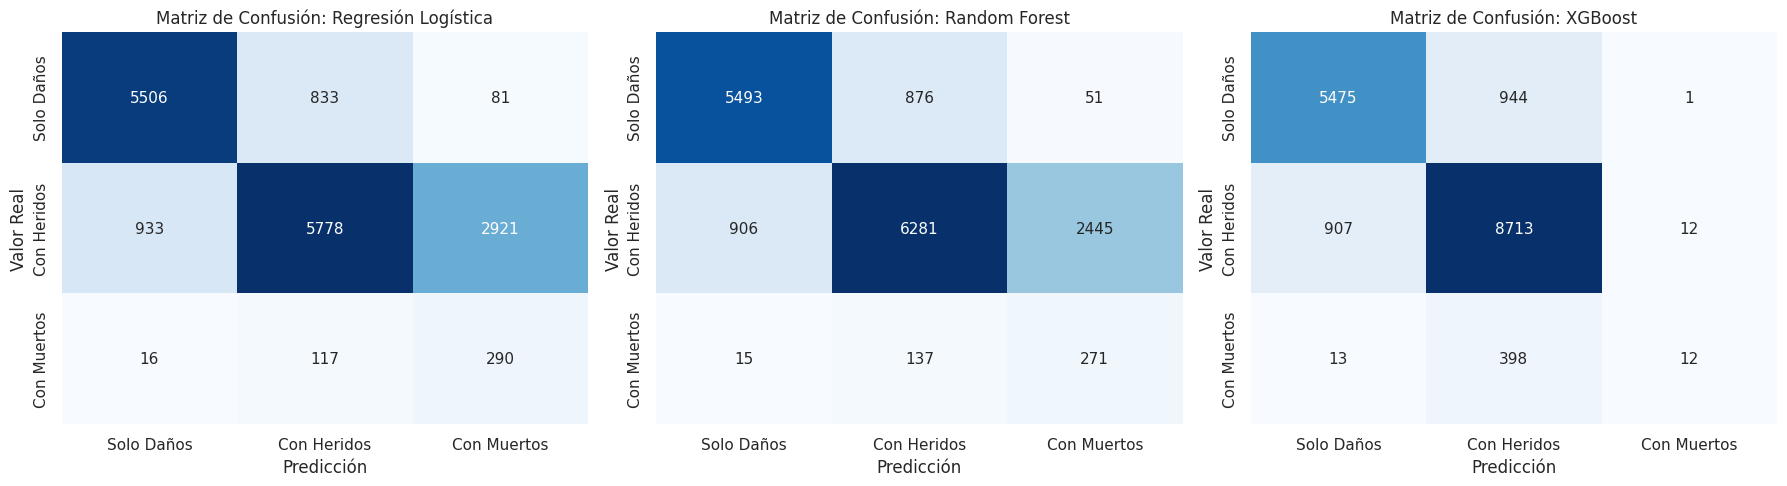

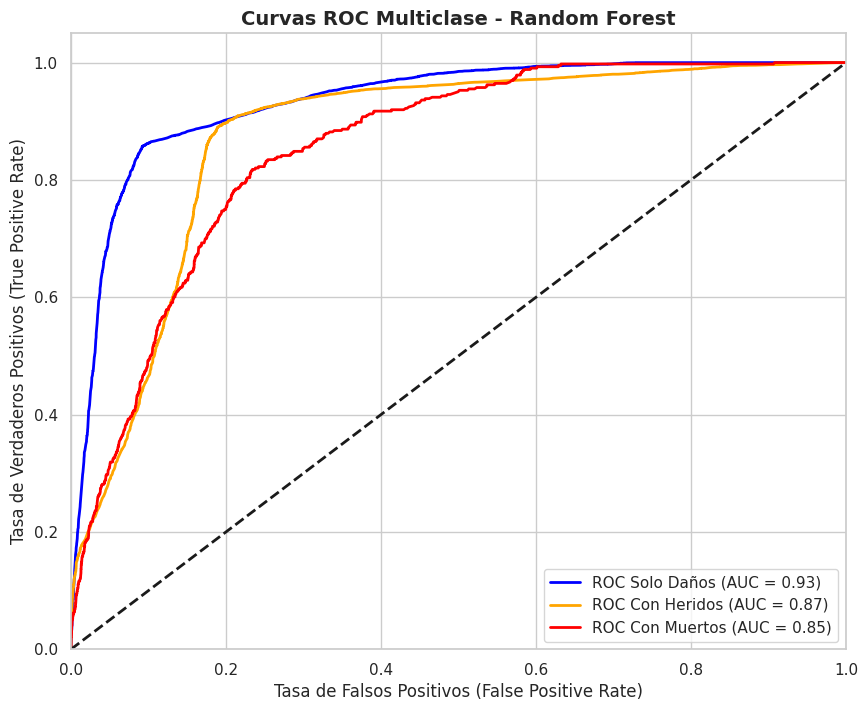

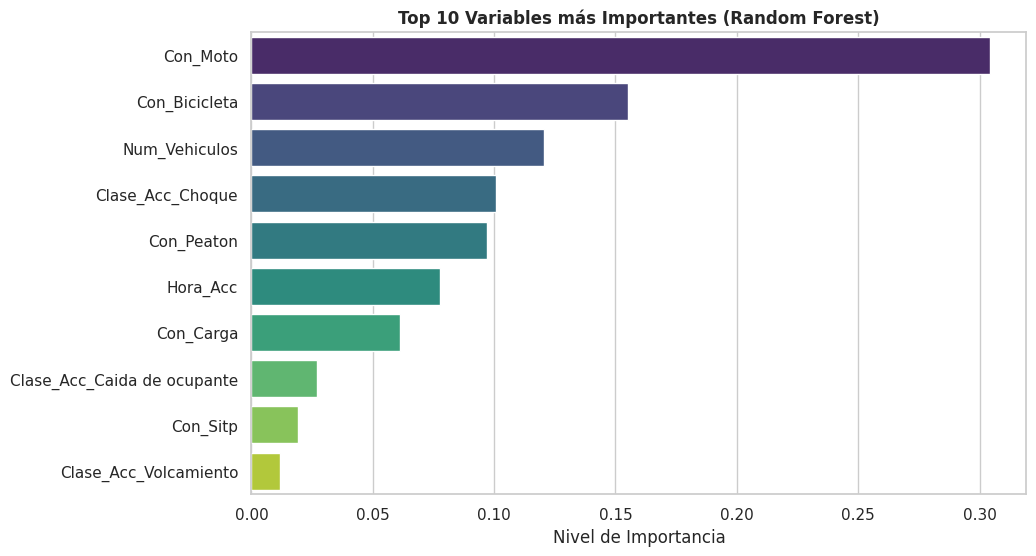

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Diccionario para guardar modelos y resultados
modelos = {
    "Regresión Logística": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42),
    # En XGBoost usamos scale_pos_weight o ajustamos los pesos internamente, aquí usaremos parámetros base para multiclase
    "XGBoost": xgb.XGBClassifier(objective='multi:softprob', num_class=3, random_state=42)
}

resultados_proba = {}
resultados_pred = {}

print("2. ENTRENANDO MODELOS (Esto puede tomar un par de minutos)...\n")

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    # Predecir clases exactas
    resultados_pred[nombre] = modelo.predict(X_test)
    # Predecir probabilidades (necesario para el AUC y ROC)
    resultados_proba[nombre] = modelo.predict_proba(X_test)

    print(f"--- Reporte de {nombre} ---")
    # Los nombres de las clases en orden: 0, 1, 2
    nombres_clases = ['Solo Daños', 'Con Heridos', 'Con Muertos']
    print(classification_report(y_test, resultados_pred[nombre], target_names=nombres_clases))

print("\n3. GENERANDO GRÁFICAS DE ANÁLISIS...\n")

# --- GRÁFICA 1: MATRICES DE CONFUSIÓN ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (nombre, pred) in enumerate(resultados_pred.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=nombres_clases, yticklabels=nombres_clases)
    axes[i].set_title(f'Matriz de Confusión: {nombre}')
    axes[i].set_ylabel('Valor Real')
    axes[i].set_xlabel('Predicción')
plt.tight_layout()
plt.show()

# --- GRÁFICA 2: CURVA ROC MULTICLASE (Para el mejor modelo, asumiremos XGBoost o RF) ---
# Vamos a graficar la curva ROC para el modelo Random Forest como ejemplo detallado
modelo_plot = "Random Forest"
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
y_score = resultados_proba[modelo_plot]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
colores = ['blue', 'orange', 'red']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colores[i], lw=2,
             label=f'ROC {nombres_clases[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Tasa de Verdaderos Positivos (True Positive Rate)')
plt.title(f'Curvas ROC Multiclase - {modelo_plot}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

# --- GRÁFICA 3: IMPORTANCIA DE VARIABLES (Random Forest) ---
importancias = modelos["Random Forest"].feature_importances_
nombres_vars = X_train.columns

df_imp = pd.DataFrame({'Variable': nombres_vars, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10) # Top 10

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')
plt.title('Top 10 Variables más Importantes (Random Forest)', fontweight='bold')
plt.xlabel('Nivel de Importancia')
plt.ylabel('')
plt.show()

Creación de Clústeres Espaciales (K-Means)

1. GENERANDO CLÚSTERES ESPACIALES...


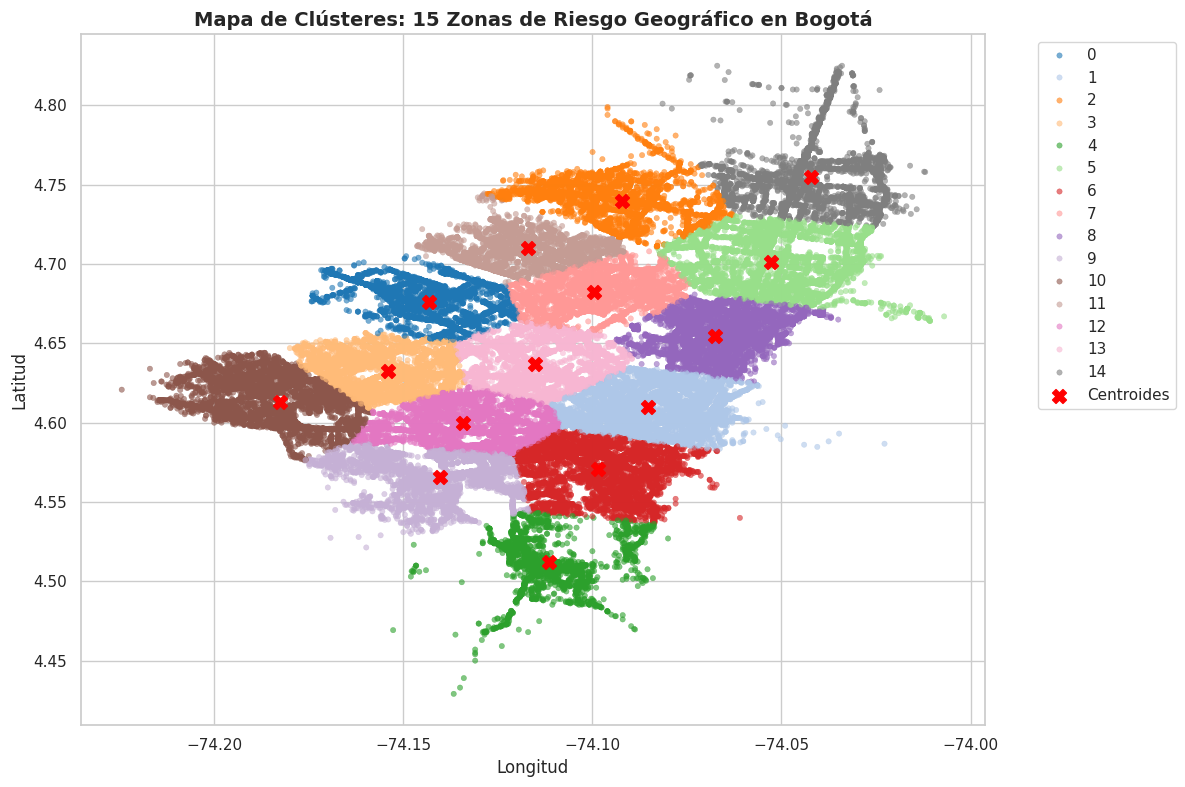


--- PERFIL DE RIESGO POR CLÚSTER ---


Gravedad_Indicador_Tradicional,Con Heridos,Con Muertos,Solo Daños,% Mortalidad
Zona_Riesgo_Cluster,,,,
4,1640,111,634,4.654088
9,3405,194,1537,3.777259
10,4550,198,1784,3.031231
12,3726,176,2050,2.956989
6,3968,172,1809,2.891242


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

print("1. GENERANDO CLÚSTERES ESPACIALES...")

# 1. Preparar las coordenadas
# Filtramos nulos y valores extremos fuera de Bogotá
df_geo = df_siniestros.dropna(subset=['Latitud', 'Longitud']).copy()
df_geo = df_geo[(df_geo['Latitud'] > 4.4) & (df_geo['Latitud'] < 4.9) &
                (df_geo['Longitud'] > -74.3) & (df_geo['Longitud'] < -73.9)]

coords = df_geo[['Latitud', 'Longitud']]

# 2. Entrenar el modelo K-Means
# Elegimos 15 clústeres como punto de partida (puedes ajustar este número)
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_geo['Zona_Riesgo_Cluster'] = kmeans.fit_predict(coords)

# 3. Visualización de los Clústeres (Scatter Plot)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Longitud', y='Latitud', hue='Zona_Riesgo_Cluster',
                palette='tab20', data=df_geo, s=15, alpha=0.6, edgecolor=None)

# Dibujar los centroides (el "corazón" de cada zona de riesgo)
centroides = kmeans.cluster_centers_
plt.scatter(centroides[:, 1], centroides[:, 0], c='red', s=100, marker='X', label='Centroides')

plt.title(f'Mapa de Clústeres: {n_clusters} Zonas de Riesgo Geográfico en Bogotá', fontweight='bold', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Analizar la severidad por Clúster
analisis_cluster = df_geo.groupby(['Zona_Riesgo_Cluster', 'Gravedad_Indicador_Tradicional']).size().unstack(fill_value=0)
analisis_cluster['% Mortalidad'] = (analisis_cluster['Con Muertos'] / analisis_cluster.sum(axis=1)) * 100
print("\n--- PERFIL DE RIESGO POR CLÚSTER ---")
display(analisis_cluster.sort_values(by='% Mortalidad', ascending=False).head(5))

Inyectar el Clúster al Random Forest (Feature Engineering)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("2. RE-ENTRENANDO RANDOM FOREST CON DATOS CLUSTERIZADOS...\n")

# 1. Unir los clústeres al dataframe de ML preparado anteriormente
df_ml_cluster = df_preparacion.merge(df_geo[['Codigo_Accidente', 'Zona_Riesgo_Cluster']], on='Codigo_Accidente', how='inner')

# Seleccionar variables (ahora incluimos el clúster)
variables_usar = ['Gravedad_Indicador_Tradicional', 'Hora_Acc', 'Dia_Semana_Acc',
                  'Clase_Acc', 'Num_Vehiculos', 'Zona_Riesgo_Cluster']
variables_binarias = ['Con_Moto', 'Con_Bicicleta', 'Con_Peaton', 'Con_Carga', 'Con_Sitp']

df_ml_cluster = df_ml_cluster[variables_usar + variables_binarias].copy()

# 2. Limpieza y Transformación (SOLUCIÓN DEL ERROR)
df_ml_cluster['Hora_Acc'] = pd.to_numeric(df_ml_cluster['Hora_Acc'], errors='coerce')
# Solo eliminamos filas si falta la hora o la gravedad, NO si faltan bicicletas o peatones
df_ml_cluster = df_ml_cluster.dropna(subset=['Hora_Acc', 'Gravedad_Indicador_Tradicional'])

for col in variables_binarias:
    df_ml_cluster[col] = df_ml_cluster[col].apply(lambda x: 1 if x == 'SI' else 0)

# 3. Codificación
df_ml_cluster = pd.get_dummies(df_ml_cluster, columns=['Dia_Semana_Acc', 'Clase_Acc', 'Zona_Riesgo_Cluster'], drop_first=True)

mapa_target = {'Solo Daños': 0, 'Con Heridos': 1, 'Con Muertos': 2}
df_ml_cluster['Target'] = df_ml_cluster['Gravedad_Indicador_Tradicional'].map(mapa_target)

X_c = df_ml_cluster.drop(['Gravedad_Indicador_Tradicional', 'Target'], axis=1)
y_c = df_ml_cluster['Target']

# 4. Partición y Entrenamiento
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.20, random_state=42, stratify=y_c)

print(f"✅ Datos listos para entrenar: {X_train_c.shape[0]} filas con clústeres inyectados.")

rf_cluster = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=12, random_state=42)
rf_cluster.fit(X_train_c, y_train_c)

# 5. Evaluación
pred_c = rf_cluster.predict(X_test_c)
print("\n--- Reporte de Random Forest (CON Clústeres Espaciales) ---")
print(classification_report(y_test_c, pred_c, target_names=['Solo Daños', 'Con Heridos', 'Con Muertos']))

2. RE-ENTRENANDO RANDOM FOREST CON DATOS CLUSTERIZADOS...

✅ Datos listos para entrenar: 65888 filas con clústeres inyectados.

--- Reporte de Random Forest (CON Clústeres Espaciales) ---
              precision    recall  f1-score   support

  Solo Daños       0.86      0.86      0.86      6419
 Con Heridos       0.87      0.69      0.77      9631
 Con Muertos       0.10      0.58      0.17       423

    accuracy                           0.75     16473
   macro avg       0.61      0.71      0.60     16473
weighted avg       0.84      0.75      0.79     16473

